# Sistema de predicción de ventas

#### El objetivo de este proyecto es estimar la evolución del ritmo de ventas en los próximos meses, con el fin de determinar el espacio de almacenamiento necesario para reubicar el almacén de la empresa en una nueva localización. Esta estimación se basa en la tendencia creciente de ventas desde la creación de la empresa

### 1. Exportacion de Librerias necesarias, descarga y exploracion del Dataset 

In [9]:
# Librerias necesarias 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import os
import numpy as np
import warnings
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
warnings.filterwarnings("ignore")
from statsmodels.tsa.stattools import adfuller
from IPython.display import display

In [6]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/alternative-time-series-project/main/sales.csv"
df = pd.read_csv(url)

,sales
date,
2022-09-03 17:10:08.079328,55.292157
2022-09-04 17:10:08.079328,53.803211
2022-09-05 17:10:08.079328,58.141693
2022-09-06 17:10:08.079328,64.530899
2022-09-07 17:10:08.079328,66.013633


,sales
count,366.000000
mean,524.963968
std,275.089698
min,53.803211
25%,290.186822
50%,520.699468
75%,763.289263
max,1000.482785


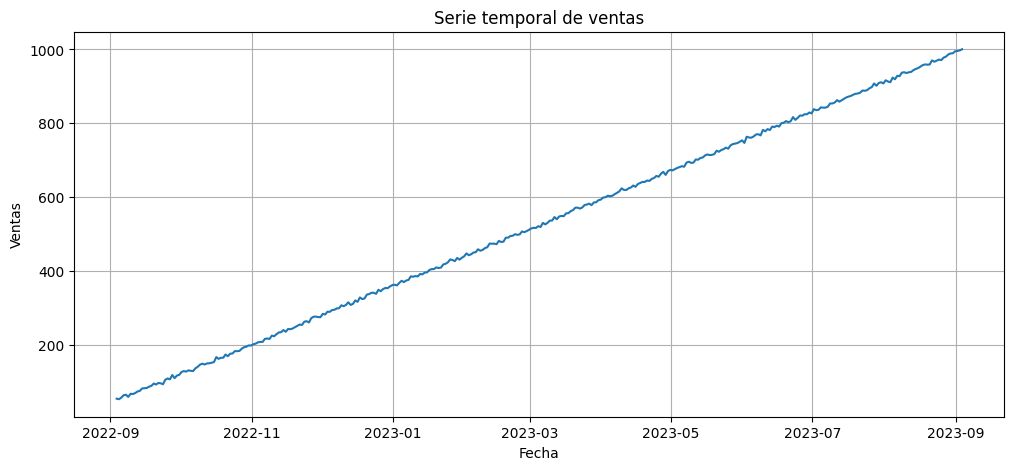

In [7]:
#Preprocesado y visualización inicial
# Convertir y ordenar
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').set_index('date')

# Mostrar info básica
display(df.head())
display(df.describe())

# Tensor (unidad mínima entre timestamps)
tensor = df.index.to_series().diff().min()
# Mostrar tensor (Jupyter mostrará el Timedelta)
tensor

# Gráfica de la serie completa
plt.figure(figsize=(12,5))
plt.plot(df.index, df['sales'])
plt.title("Serie temporal de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()


- La primera tabla con fechas y ventas.

Son las primeras 5 filas de este DataFrame, que muestran:

Índice (date): la fecha y hora exacta de cada registro (en tu caso, un registro por día, siempre a la misma hora).

Columna sales: las ventas registradas ese día (valor numérico).

- La segunada tabla "describe()" nos dice esto del negocio:

Hay tendencia de crecimiento, porque empezo con valores alrededor de 50–60 y llego a ~1000.

Alta variabilidad: algunos días se vende  muy poco y otros muchísimo (esto se ve por el alto std y la gran diferencia entre el mínimo y el máximo).

No parece haber ventas negativas ni valores nulos, lo cual es bueno para modelar.

Explicación: la salida tensor te indica la unidad mínima (por ejemplo 1 days 00:00:00 = diario). La gráfica te permite ver si hay tendencia.



### Comprobar estacionariedad (ADF)

Qué hace: ejecuta el test ADF (Dickey–Fuller aumentado) y devuelve las estadísticas relevantes (ADF, p-value, valores críticos).


In [8]:
adf_res = adfuller(df['sales'])
adf_out = {
    "adf_stat": adf_res[0],
    "p_value": adf_res[1],
    "n_lags": adf_res[2],
    "n_obs": adf_res[3],
    "critical_values": adf_res[4]
}
adf_out

{'adf_stat': np.float64(0.545414193706378),
 'p_value': np.float64(0.9861899815311064),
 'n_lags': 13,
 'n_obs': 352,
 'critical_values': {'1%': np.float64(-3.4490648539347544),
  '5%': np.float64(-2.8697861692116478),
  '10%': np.float64(-2.5711631253228306)}}

La serie tiene tendencia y posiblemente variabilidad creciente p_value: 0.9861 → muy superior a 0.05, por lo que no es estacionaria.

### ACF y PACF 
Qué hace: dibuja la ACF y PACF para orientación en la elección de p y q.

<Figure size 1200x400 with 0 Axes>

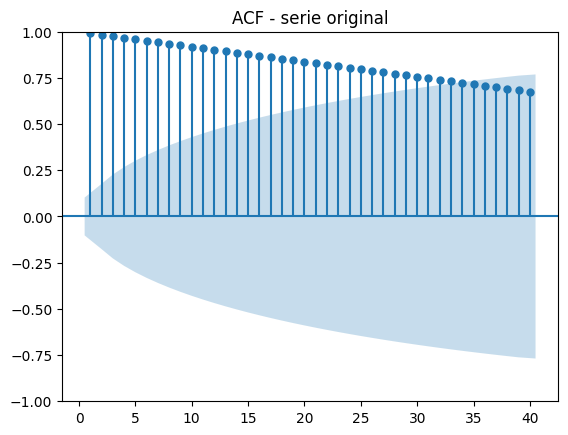

<Figure size 1200x400 with 0 Axes>

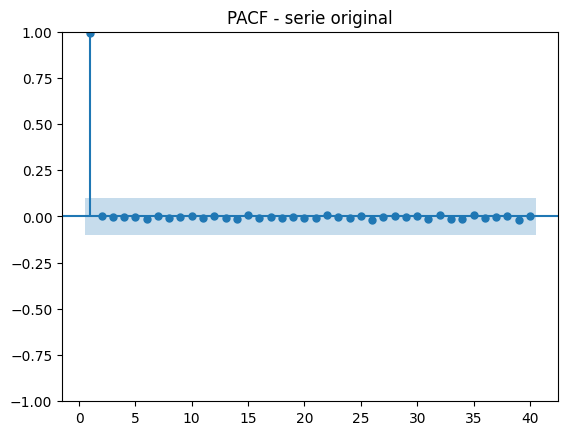

In [10]:
plt.figure(figsize=(12,4))
plot_acf(df['sales'], lags=40, zero=False)
plt.title("ACF - serie original")
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(df['sales'], lags=40, zero=False, method='ywm')
plt.title("PACF - serie original")
plt.show()